# Comparing models to fMRI data using BayesCompare
This tutorial shows how to use the `encoding` module's functions in BayesCompare in order to compare models to brain data. We will focus on how to prepare the brain data, extract the model's representations, and finally compute the comparisons using BayesCompare.

## Obtaining the dataset
In order to download the data, please fill the [NSD Data Access Agreement Form](https://docs.google.com/forms/d/e/1FAIpQLSduTPeZo54uEMKD-ihXmRhx0hBDdLHNsVyeo_kCb8qbyAkXuQ/viewform). You will then receive an email with a link to the documentation and instructions on how to access the data. For this tutorial, we will use the [NSD Synthetic dataset](https://cvnlab.slite.page/p/wLlJyfWRvg/Functional-data-nsdsynthetic). After filling out the form, we can download the data using `aws-cli`

In [1]:
%%bash
mkdir encoding_data
aws s3 sync --no-sign-request s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic encoding_data/stimuli
aws s3 sync --no-sign-request s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic_subj01 encoding_data/stimuli
aws s3 sync --no-sign-request s3://natural-scenes-dataset/nsddata/experiments/nsdsynthetic encoding_data/nsdsynthetic
for i in {1..8}; do
  aws s3 cp --no-sign-request s3://natural-scenes-dataset/nsddata_betas/ppdata/subj0${i}/func1pt8mm/nsdsyntheticbetas_fithrf/betas_nsdsynthetic.hdf5 encoding_data/data/subj0${i}/betas_nsdsynthetic.hdf5;
  aws s3 cp --no-sign-request s3://natural-scenes-dataset/nsddata/ppdata/subj0${i}/func1pt8mm/roi/prf-visualrois.nii.gz encoding_data/rois/subj0${i}/prf-visualrois.nii.gz;
done

download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic005.png to encoding_data/stimuli/nsdsynthetic005.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic006.png to encoding_data/stimuli/nsdsynthetic006.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic007.png to encoding_data/stimuli/nsdsynthetic007.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic008.png to encoding_data/stimuli/nsdsynthetic008.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic013.png to encoding_data/stimuli/nsdsynthetic013.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic010.png to encoding_data/stimuli/nsdsynthetic010.png
download: s3://natural-scenes-dataset/nsddata/stimuli/nsdsynthetic/nsdsynthetic/nsdsynthetic009.png to encoding_data/stimuli/nsdsy

## Imports

In [120]:
import h5py
import itertools
import os

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.io as sio

from scipy.stats import zscore, beta

## Preparing fMRI data
First, we need to get voxel data from the NSD files. For that, we will load the voxels corresponding to a single ROI (V1) in memory. The data is available in hdf5 format, which allows us to only load the voxels we select in memory, instead of the whole array. We will load the V1 ROI definitions using `prf-visualrois.nii.gz`. In order to use a different visual ROI, you can change the index used for the voxel selection. Additional ROIs can be selected using the same logic shown below (follow the documentation [here](https://cvnlab.slite.page/p/X_7BBMgghj/ROIs) for other ROIs).

In [6]:
# Define data path and sub list
data_dir = 'encoding_data/data'
subjects = [f"subj0{i}" for i in range(1, 9)]  # [subj01, ..., subj08]

betas_fnames = [os.path.join(data_dir, sub, "betas_nsdsynthetic.hdf5") for sub in subjects]

# Load V1 ROI mask from NSD data
#for idx, sub in enumerate(subjects):
sub_fname = betas_fnames[0]
sub = subjects[0]
print(f"Loading ROI for {sub}...")
roi_path = f'encoding_data/rois/{sub}/prf-visualrois.nii.gz'  # Load a different mask to use other ROIs
roi_img = nib.load(roi_path)
roi_data = roi_img.get_fdata()

# V1 is labeled as 1 in prf-visualrois -- change the number to use other visual ROI
v1_mask = (roi_data == 1).T  # Need transpose to match betas dimensions
target_idx = np.where(v1_mask)
print(f"V1 voxels: {v1_mask.sum()}")

# Get betas
with h5py.File(sub_fname, 'r') as f:
    sub_betas = np.stack([f['betas'][..., idx[0], idx[1], idx[2]] for idx in zip(*target_idx)]).astype(float) / 300
print(f"Shape of V1 betas for {sub}: {sub_betas.shape}")  # should be (num_voxels_in_V1, 744)

Loading ROI for subj01...
V1 voxels: 594
Shape of V1 betas for subj01: (594, 744)


## Obtaining image IDs
The second thing we need is to obtain information about the images shown to the subjects (the first dimension in our betas). We only need to know the image number corresponding to each image, which we can obtain from the `nsdsynthetic_expdesign.mat` file. Finally, we can make a dataframe where the rows are our voxels and the columns are the image numbers.

In [76]:
# Load NSD synthetic experimental design
expdesign_path = 'encoding_data/nsdsynthetic/nsdsynthetic_expdesign.mat'
expdesign = sio.loadmat(expdesign_path)

# master_ordering contains the image IDs used in order
master_ordering = expdesign['masterordering'][0]  # shape (744,)

# Make DataFrame containing image number
beta_df = pd.DataFrame(sub_betas, columns=master_ordering)

The reason we create this dataframe is to have a convenient way to re-arrange the columns so repetitions of the same image are grouped, which is necessary for later steps:

In [79]:
# Group columns by image
unique_imgs = beta_df.columns.unique()
beta_df = beta_df.loc[:, unique_imgs]  # Columns corresponding to the same image are grouped together
print(beta_df.head())

         198        198        231       231        196       196        152  \
0  24.146667 -14.536667  19.020000 -1.480000  21.413333 -5.223333  32.186667   
1  -3.590000  -7.700000   0.963333 -2.450000   3.623333 -8.330000   4.503333   
2  -7.293333  -0.220000  -7.683333  3.516667  -1.790000  1.540000   0.996667   
3  20.123333  -3.573333  13.460000  2.966667  12.616667  3.193333  23.473333   
4   0.960000  -0.593333  -2.450000  3.710000   0.943333  3.106667   4.416667   

        152        53        53   ...        212        212        267  \
0 -8.143333  21.683333  6.730000  ...   5.500000  12.420000   4.976667   
1  3.230000   4.440000  6.670000  ...  10.346667   5.103333  10.960000   
2  2.493333   5.303333  8.256667  ...  -1.370000   0.740000  -1.220000   
3 -1.013333  15.763333  9.640000  ...   2.166667   9.270000   1.706667   
4  2.153333   1.246667  9.903333  ...   4.320000   3.320000   3.650000   

        267       223       223        223       223        154        154

## Obtaining noise estimates and mean activations
The BayesCompare method requires an estimation of the noise present in each voxel in order to compute the similarity with different models. We can estimate the noise in the data using the `voxel_reliability` function provided by BayesCompare. To make things easier, we will normalize the data so the total variance of each voxel is equal to 1.

In [80]:
from BayesCompare.encoding_utils import voxel_reliability

# Normalize data - we keep it in DataFrame shape in order to get the mean activations per image later
norm_betas = pd.DataFrame(
    zscore(beta_df.values, axis=1),
    beta_df.index,
    beta_df.columns
)

# Obtain reliability, noise variance and total variance estimates from the data
voxel_data = norm_betas.values
stim_list = norm_betas.columns.values
reliability, noise_var, total_var = voxel_reliability(voxel_data, stim_list)
signal_var = total_var - noise_var

# We can check that the total variance for each voxel is close to 1
print(f"Number of voxels: {total_var.shape[0]}\nTotal variance across all voxels: {total_var.sum()}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17040279762022897s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0066680908203125s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 109 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 143 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.018457412719726562s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 204 tasks      | elapsed:    2.2s
[Parallel(n_job

Number of voxels: 594
Total variance across all voxels: 594.7994616419919


[Parallel(n_jobs=-1)]: Done 594 out of 594 | elapsed:    2.5s finished


Now that we have estimated the noise variance for each voxel, we can use them for our evaluation in two different ways:
- The first one is to use the estimated value for each voxel, making each voxel have it's own noise variance (see histogram below)
- The second one is to sample a set of representative noise values from the distribution of noise variance, and use each one of them in all voxels (see lines below)
We will illustrate both methods. In order to obtain the values for the second method, we can use the `sample_noise_values` function. What it does it fit a beta distribution to the noise estimates and sample values from its cumulative distribution function

Note that, for this example, we are only using voxels from a single ROI. In real analysis, the sampling process is done over the distribution of noise across all considered voxels.

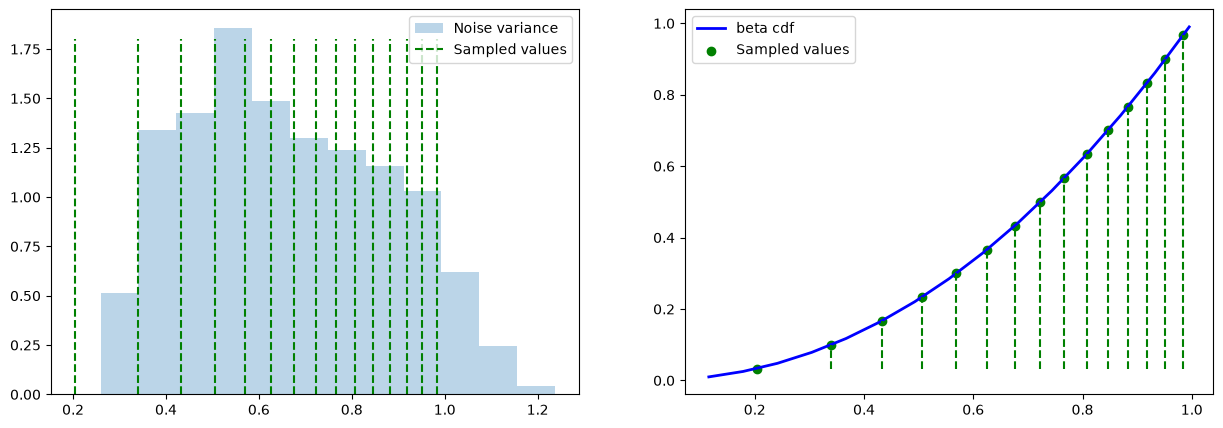

In [82]:
from BayesCompare.encoding_utils import sample_noise_values

n_vals = 15
noise_values, a, b = sample_noise_values(noise_var=noise_var, total_var=total_var, n_vals=n_vals, return_params=True)

# Visualize the sample noise values over the histogram
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].hist(noise_var / total_var, density=True, bins='auto', alpha=0.3, label="Noise variance")
axs[0].vlines(noise_values, ymin=0, ymax=1.8, color='g', label="Sampled values", linestyles="--")
axs[0].legend()

# CDF visualization. The code below replicates part of the process `sample_noise_values` uses
x = np.linspace(beta.ppf(0.01, a, b), beta.ppf(0.99, a, b), n_vals)
cdf = beta(a, b).cdf(x)
n_bins = n_vals * 2
y_vals = np.linspace(1 / n_bins, (n_bins - 1) / n_bins, n_vals)
x_vals = beta.ppf(y_vals, a, b)

axs[1].plot(x, cdf, "b-", lw=2, label="beta cdf")
axs[1].scatter(x_vals, y_vals, color="g", label="Sampled values")
axs[1].vlines(x_vals, ymin=y_vals.min(), ymax=y_vals, colors="g", linestyles="--")
axs[1].legend()
plt.show()

### Obtaining mean activations per image
For our analysis, we consider the mean activation for each of the presented images. We average over columns with the same ID in our brain dataframe to obtain it. This gives us the array we will use in our evaluation

In [87]:
# Obtain mean activations by image and extract array
mean_betas = norm_betas.T.groupby(level=0, sort=False).mean().T  # shape (n_voxels, 284)
y = mean_betas.values
print(mean_betas.head())

        198       231       196       152       53        18        23   \
0 -0.267956  0.029654 -0.021011  0.273721  0.437725  0.262687  0.645576   
1 -0.673555 -0.130689 -0.308998  0.379875  0.566861 -0.172405 -0.029074   
2 -0.850722 -0.561130 -0.222215  0.101412  0.972784 -0.353858  0.066728   
3  0.249856  0.241717  0.201021  0.639870  0.834107  0.406961  0.873592   
4 -0.416275 -0.305830  0.039104  0.350657  0.916893  0.101744 -0.107916   

        180       25        34   ...       134       164       191       205  \
0  0.698806 -0.241310  0.684920  ...  0.224307  0.017769  0.546811  0.987533   
1  0.244389  0.012504  0.461093  ...  0.854076  1.078163  0.789286  1.599987   
2  0.084683  0.057714  0.265245  ...  0.409464  0.241882  0.900386 -0.240098   
3  0.614353 -0.016973  1.264596  ...  0.312548 -0.160616  0.848625  1.014926   
4 -0.521363 -0.044348  0.322634  ...  0.565777  0.790376  1.202895  1.388756   

        94        174       212       267       223       154  
0 -0

## Extracting model features
Now that our brain data is ready, we need to obtain the representations from the models we are considering. We will use a few layers from a simple model. Please check the `cov_extractor_tutorial.ipynb` tutorial for more information on this process.

### Loading the model

In [103]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.eval()

# Define the preprocessing transform for the images
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Model loaded successfully.")

Model loaded successfully.


### Loading the images
It is important to load the images in the same order they appear on the data. The dimension corresponding to the stim must match between the brain data and the model representations

In [107]:
# Load images
image_ids = mean_betas.columns.values
stim_dir = "encoding_data/stimuli"
image_files = [f"{stim_dir}/nsdsynthetic{img_id:03}.png" for img_id in image_ids]

# Load and pre-process images
images = [preprocess(Image.open(img_file).convert('RGB')) for img_file in image_files]
input_images = torch.stack(images)  # Shape: (num_images, 3, 224, 224)
print(f"Loaded {len(images)} stimulus images.")

Loaded 284 stimulus images.


### Extracting covariance matrices
For this example, we will use three layers from a single model. BayesCompare provides utilities to extract different layers from different types of models, all of which is explained in `cov_extractor_tutorial.ipynb`

In [115]:
from BayesCompare import cov_extractor

# Select the layers to use (see the cov extraction tutorial for more details)
layer_list = ["conv2d_1_1", "relu_7_26", "linear_1_175"]
covs = cov_extractor(model, input_images, layer_list, compute_covs=True)

## Running the Evluation
Now that we have our model representations and brain data ready, we can finally run the evaluation. We will run our evaluation separately for each layer of the model. If you remember, we mentioned earlier that we can use the noise estimates of the data in two ways: use them as they are or use a list of sampled values. We will see how to run the analysis for both methods. The function used to evaluate our models is `loglik_score`.

In [ ]:
from BayesCompare.encoding import loglik_score
from BayesCompare.cov_utils import trace_norm

from scipy.special import logsumexp

est_results = {}
fit_results = {}
# Iterate over layers
for layer_name, cov in covs.items():
    # Cov matrix needs to be normalized so its trace is equal to N (number of stim)
    norm_cov = trace_norm(cov).numpy()
    # Additionally, we need to know how many times each image was presented (in order)
    img_weights = np.array([len(list(group)) for _, group in itertools.groupby(norm_betas.columns.values)])

    # We first do the `noise_estimation` procedure, i.e. using the estimated noise value for each voxel
    print(f"Estimating log-likelihood using noise estimates for layer {layer_name}")
    est_score = loglik_score(  # shape (n_voxels,)
        norm_cov=norm_cov,
        activations=y,
        noise_var=noise_var,
        signal_var=signal_var,
        img_weights=img_weights,
    )

    est_results[layer_name] = est_score

    # When using the sampled noise values, we use each one for all voxels. What we do is to iterate over the list of
    # values and pass the value as the `noise_var` parameter. At the end, we combine the results over all noise values
    # to obtain the marginal likelihood over the sampled values.
    print(f"Estimating log-likelihood using fitted noise values for layer {layer_name}")
    fit_list = []
    for noise_val in noise_values:
        print(f"  Using noise_val: {noise_val}")
        score = loglik_score(
            norm_cov=norm_cov,
            activations=y,
            noise_var=noise_val,
            img_weights=img_weights,
        )
        fit_list.append(score)
    fit_score = np.stack(fit_list, axis=0)  # shape (n_noise, n_voxels)
    fit_score = logsumexp(fit_score, axis=0)  # shape (n_voxels,)

## Visualizing the results
Now we have estimated the likelihood that each of the considered layers had of producing the observed brain data. We can normalize such likelihoods into a proper posterior distribution to visualize the winning model.